# MNIST Classification with SVM

## Imports

Import all required libraries for data loading, model training, evaluation, and visualization.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

## Data Loading & Preprocessing

Load the MNIST dataset via `fetch_openml`, downsample to 5,000 samples for faster SVM training, split 80/20 into train and test sets, then scale pixel values using `StandardScaler`.

In [2]:
# Load MNIST
mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
X, y = mnist.data, mnist.target

# Downsample to 5,000 samples
rng = np.random.default_rng(42)
indices = rng.choice(len(X), size=5000, replace=False)
X, y = X[indices], y[indices]

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4000, 784), Test: (1000, 784)


## Data Visualization

Display a sample of 10 images from the dataset to verify the data loaded correctly and get a feel for the digit classes.

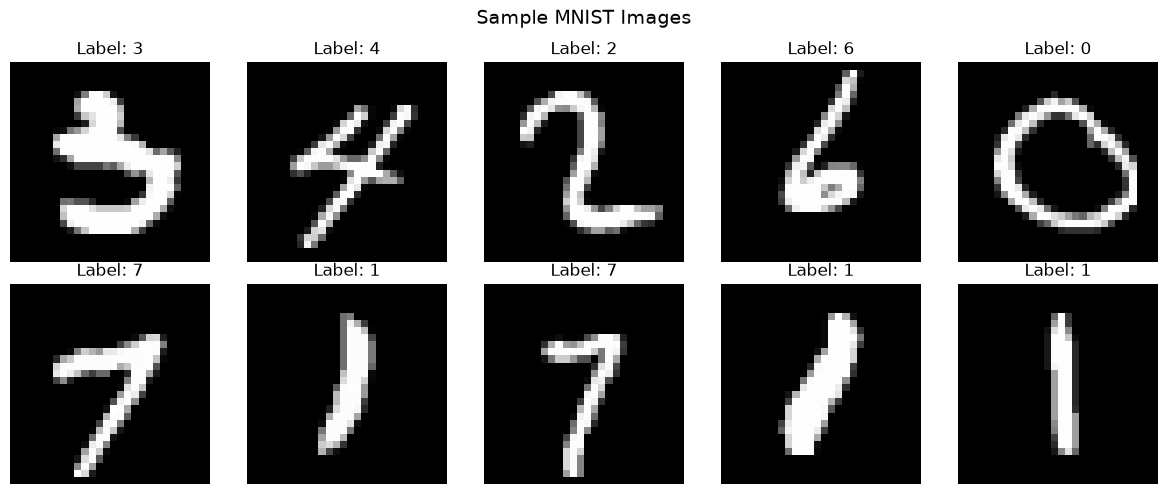

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample MNIST Images", fontsize=14)

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Model Training

Train an SVM classifier with an RBF kernel on the scaled training data, then generate predictions on the test set.

In [4]:
svm_model = SVC(kernel="rbf", C=1.0, random_state=42)
print("Training the model")
svm_model.fit(X_train, y_train)

print("Making predictions")
y_pred = svm_model.predict(X_test)

Training the model
Making predictions


## Evaluation

Compute accuracy, precision, and recall on the test set, then plot a confusion matrix to see which digits the model confuses most.


--- Final Evaluation Metrics ---
Accuracy:  0.9040
Precision: 0.9074
Recall:    0.9037


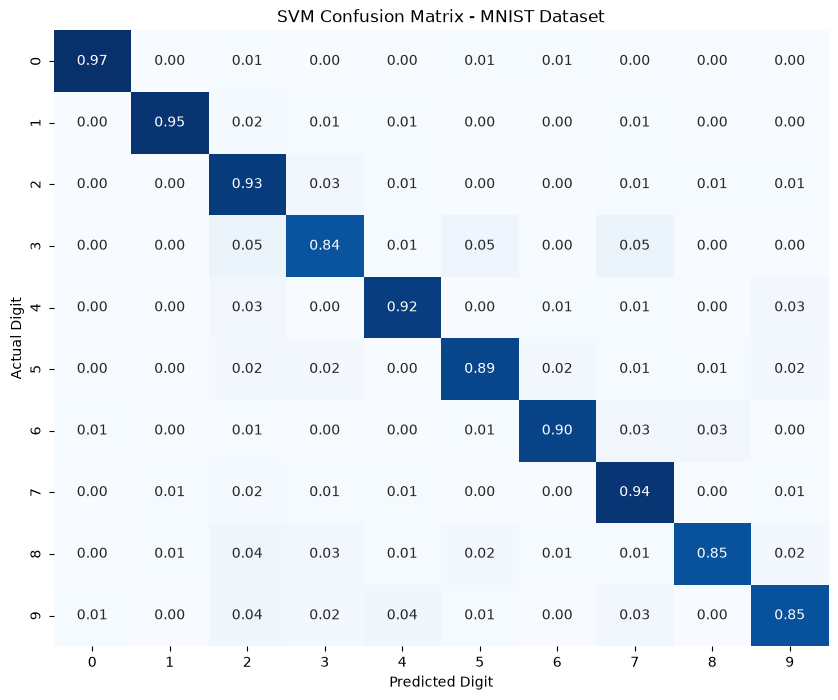

In [5]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")

print("\n--- Final Evaluation Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

# Confusion Matrix - SVM
cm = confusion_matrix(y_test, y_pred, normalize = "true")
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", cbar=False)
plt.title("SVM Confusion Matrix - MNIST Dataset")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.show()